In [29]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import arviz as az
import json

In [30]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/new_data_MZB.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')
df_ont_T2 = pd.read_excel('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/20190412_MV_Bcellnumbers_ontogeny.xlsx', sheet_name='SPLEEN_Cell number')


file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Ontogeny/Steady State-DD/T2_lossphiP(t)_rhodelta.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/SHM_T1.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        df = pkl.load(f)
else:
    raise EOFError("File is empty")

#Open csv files 
# dir_path = '/home/apoorva/Desktop/work/MZ_analysis/data/output_logistic_growth'
# csv_files = [dir_path + '/' + file for file in os.listdir(dir_path) if file.endswith('.csv')]
# print(csv_files)

# from cmdstanpy import from_csv
# data_neutral = from_csv(csv_files)
print(df_new.head(10))
print(df_ont.head(10))

                               Unnamed: 0  Age at BMT  Age at S1K  \
0  20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
1  20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
2      20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
3      20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
4        20181207_3wks_SPLEEN_001_048.fcs          74          95   
5        20181207_3wks_SPLEEN_002_049.fcs          41          62   
6        20181213_4wks_SPLEEN_001_024.fcs          74         102   
7        20181213_4wks_SPLEEN_002_025.fcs          41          69   
8   20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
9   20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   

   Days postBMT  Lamis ID      total_FM     fd_FM  frac_Ki67+_FM_donor  \
0            14    832634  2.247009e+07  0.016125             0.441377   
1            14    848687  2.440681e+07  0.013667             0.485563   
2            18   

In [31]:
file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/SHM/new_fitted_chi_T1.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_SHM = pkl.load(f)
else:
    raise EOFError("File is empty")

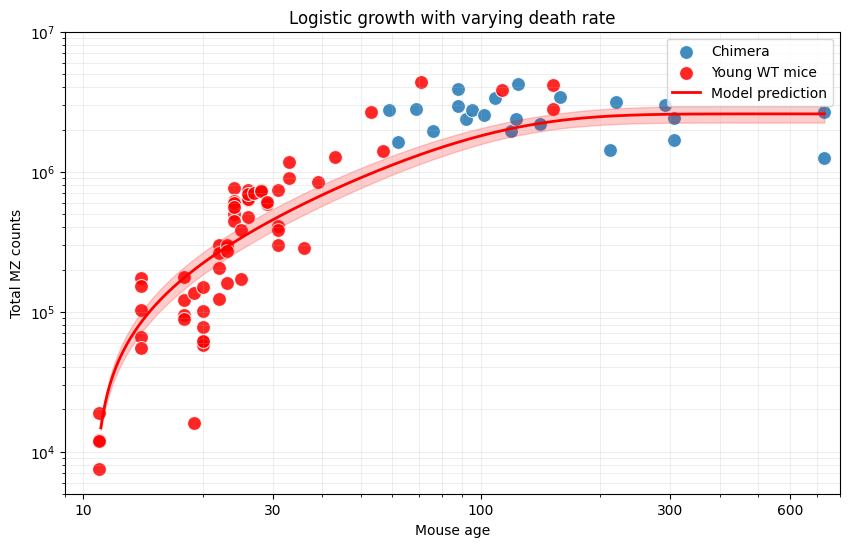

In [32]:
ts2= np.arange(11.1, 732.1, 0.1)
ts1= np.arange(45, 750, 1)
# ts1= np.arange(11, 152, 1)
# ts2 = np.arange(11, 153, 1)

# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(ts1, np.mean(data_SHM.MZ_counts_pred1, axis=0))
# plt.fill_between(ts1, np.quantile(data_SHM.MZ_counts_pred1, 0.025, axis=0), np.quantile(data_SHM.MZ_counts_pred1, 0.975, axis=0), alpha=0.2, color = 'steelblue')
plt.plot(ts2, np.mean(data_neutral.MZ_counts_pred, axis=0), color='red', label='Model prediction', linewidth=2)
plt.fill_between(ts2, np.percentile(data_neutral.MZ_counts_pred, 2.5, axis=0), np.percentile(data_neutral.MZ_counts_pred, 97.5, axis=0), alpha=0.2, color='red')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(9, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age')
plt.ylabel('Total MZ counts')
plt.title('Logistic growth with varying death rate')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()



array([<Axes: title={'center': 'rho'}>,
       <Axes: title={'center': 'M_stable'}>,
       <Axes: title={'center': 'delta'}>, <Axes: title={'center': 'K'}>],
      dtype=object)

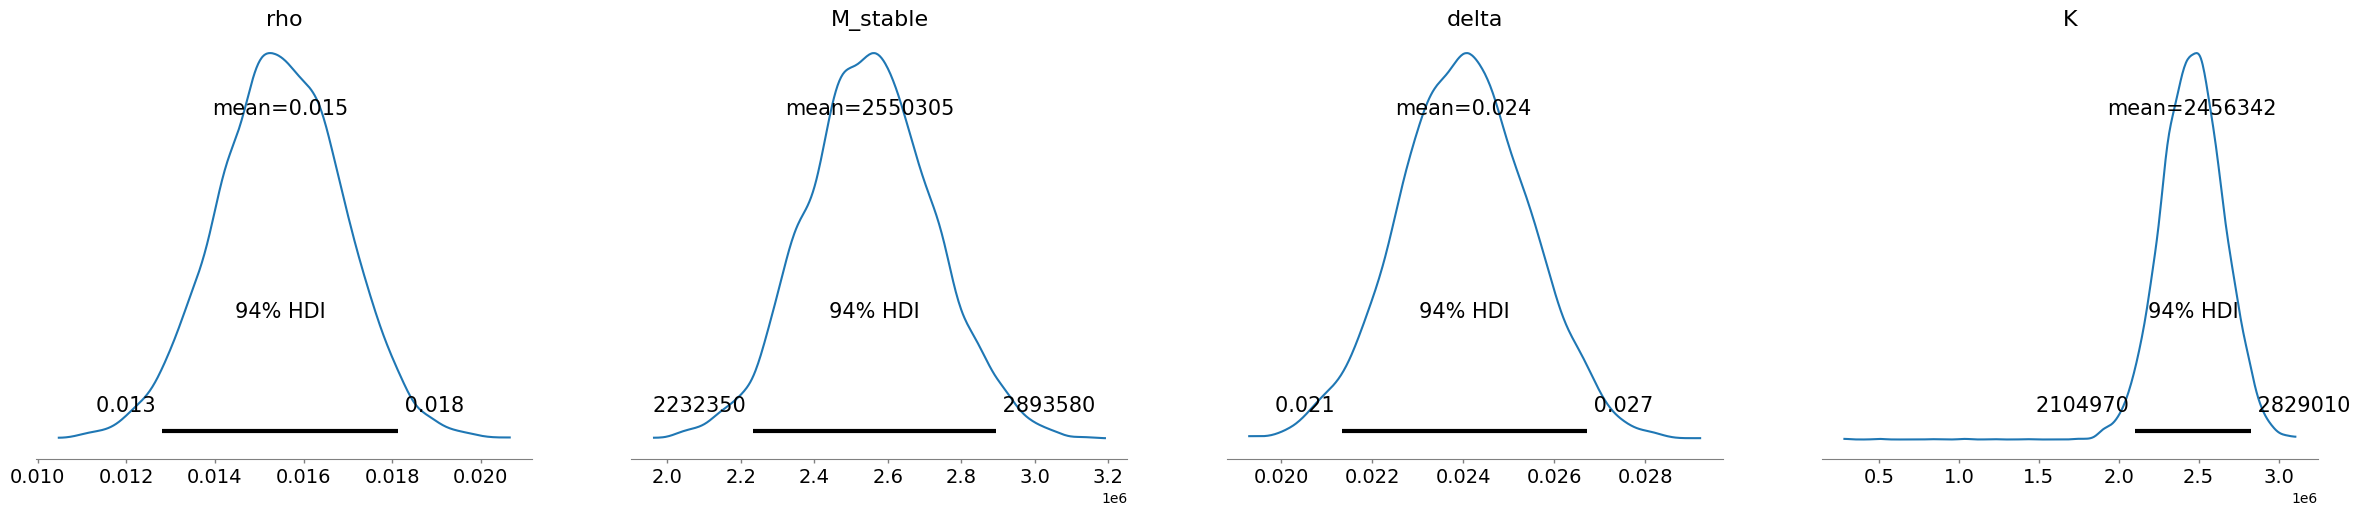

In [33]:
# Posterior distribution of parameters

# az.plot_posterior(data_neutral, var_names=['phi', 'r_phi','lambda'], kind='kde')
# az.plot_posterior(data_neutral, var_names=[ 'lamda','S','K'], kind='kde')
az.plot_posterior(data_neutral, var_names=['rho','M_stable','delta','K'], kind='kde')
# az.plot_posterior(data_neutral, var_names=['r_d', 't0'], kind='kde')



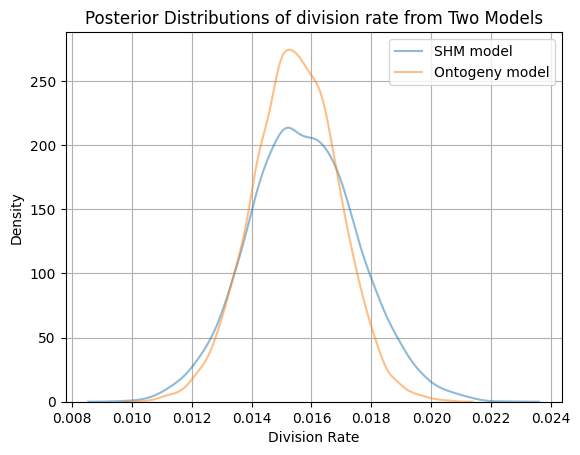

In [34]:
sns.kdeplot(df.rho, label='SHM model', alpha=0.5)
sns.kdeplot(data_neutral.rho, label='Ontogeny model', alpha=0.5)

plt.xlabel('Division Rate')
plt.ylabel('Density')
plt.title('Posterior Distributions of division rate from Two Models')
plt.legend()
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'lamda = delta - rho')

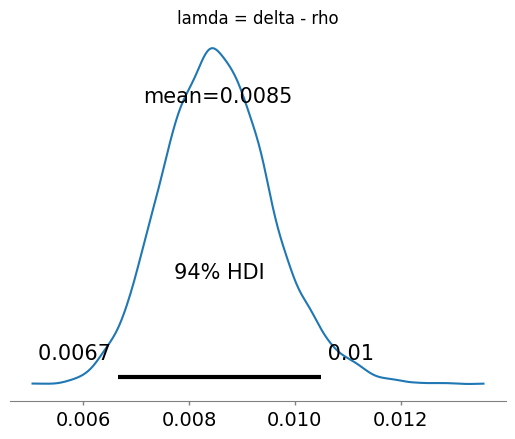

In [35]:
lamda =  data_neutral.stan_variable('delta') - data_neutral.stan_variable('rho') 
az.plot_posterior(lamda, kind='kde')
plt.title('lamda = delta - rho')

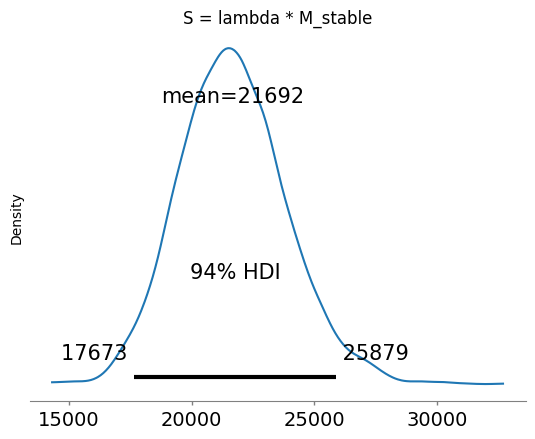

In [36]:
# Get posterior samples for 'lambda' and 'M_stable'
lambda_samples = lamda
M_stable_samples = data_neutral.stan_variable('M_stable')

S = lambda_samples * M_stable_samples

# Plot the posterior distribution for S
az.plot_posterior(S, kind='kde')

# Remove X from the plot

plt.ylabel('Density')
plt.title('S = lambda * M_stable')
plt.show()


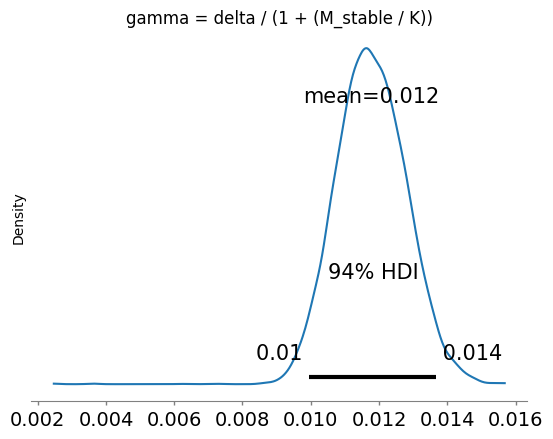

In [37]:
# Get posterior samples for 'lambda' and 'M_stable'
delta_samples = data_neutral.stan_variable('delta')
M_stable_samples = data_neutral.stan_variable('M_stable')
K_samples = data_neutral.stan_variable('K')


gamma = delta_samples / (1 +(M_stable_samples / K_samples))

# Plot the posterior distribution for gamma
az.plot_posterior(gamma, kind='kde')

# Remove X from the plot

plt.ylabel('Density')
plt.title('gamma = delta / (1 + (M_stable / K))')
plt.show()

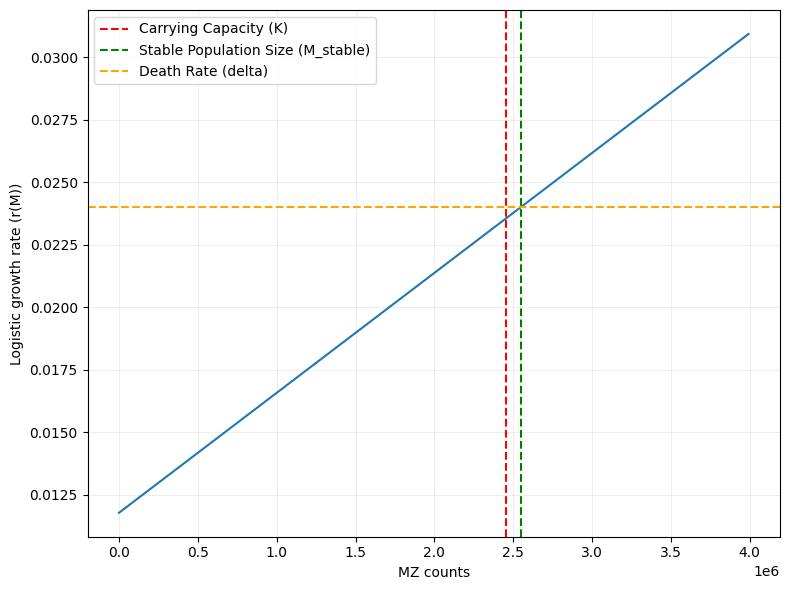

In [38]:
r = np.mean(data_neutral.delta, axis=0) / (1 + (np.mean(data_neutral.M_stable, axis=0) / np.mean(data_neutral.K, axis=0)))
def r_m(M):
    return r * (1 + (M / np.mean(data_neutral.K, axis=0)))


M = np.arange(0, np.exp(15.2), 1)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(M, r_m(M))
# axes.fill_between(np.mean(data_neutral.MZ_counts_pred, axis=0), np.quantile(r_m, 0.025, axis=0), np.quantile(r_m, 0.975, axis=0), alpha=0.3)
plt.axvline(x=np.mean(data_neutral.K, axis=0), color='red', linestyle='--', label='Carrying Capacity (K)')
plt.axvline(x=np.mean(data_neutral.M_stable, axis=0), color='green', linestyle='--', label='Stable Population Size (M_stable)')
plt.axhline(y=np.mean(data_neutral.delta), color='orange', linestyle='--', label='Death Rate (delta)')
# axes.set_ylim(0, 0.02)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xscale('log')
# axes.set_xlim(0, 750)
# axes.set_xticks([10, 30, 50, 100, 150, 200])
# axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel('Logistic growth rate (r(M))')
axes.set_xlabel('MZ counts')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.legend(loc='upper left')
# axes.set_title('Total number of source cells into MZ (/day)')
plt.tight_layout()
plt.show()

AttributeError: Unknown variable name: source_rate
Available variables are sigma, K, delta, rho, M_stable, y1, k_hat, totalMz_mean, MZ_counts_mean, parms, k_hat_pred1, MZ_counts_pred, loss_rate, log_lik_Mz, residuals_Mz

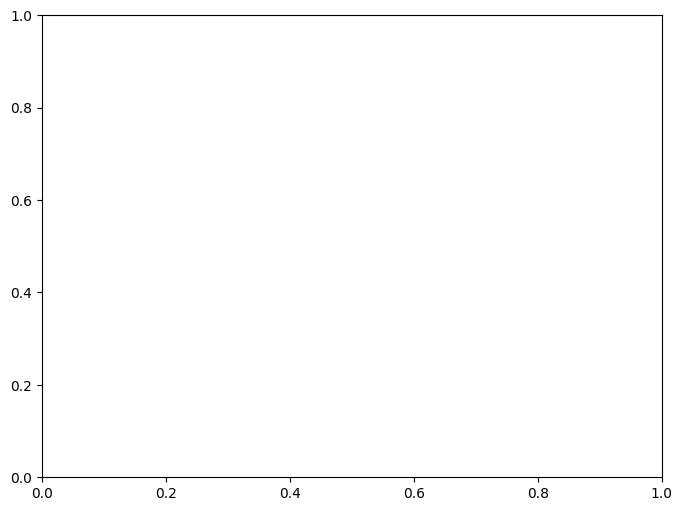

In [39]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(np.mean(data_neutral.MZ_counts_pred, axis=0), np.mean(data_neutral.source_rate, axis=0))
# axes.fill_between(np.mean(data_neutral.MZ_counts_pred, axis=0), np.quantile(data_neutral.source_rate, 0.025, axis=0), np.quantile(data_neutral.source_rate, 0.975, axis=0), alpha=0.3)
plt.axvline(x=np.mean(data_neutral.K, axis=0), color='red', linestyle='--', label='Carrying Capacity (K)')
plt.axvline(x=np.mean(data_neutral.M_stable, axis=0), color='green', linestyle='--', label='Stable Population Size (M_stable)')
plt.axhline(y=-0.0092, color='orange', linestyle='--', label='Loss Rate (lambda)')
# axes.set_ylim(0, 0.02)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xscale('log')
# axes.set_xlim(0, 750)
# axes.set_xticks([10, 30, 50, 100, 150, 200])
# axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel(' ')
axes.set_xlabel('MZ counts')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.legend()
# axes.set_title('Total number of source cells into MZ (/day)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3065760/4057362616.py:10: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes.set_xlim(0, 750)


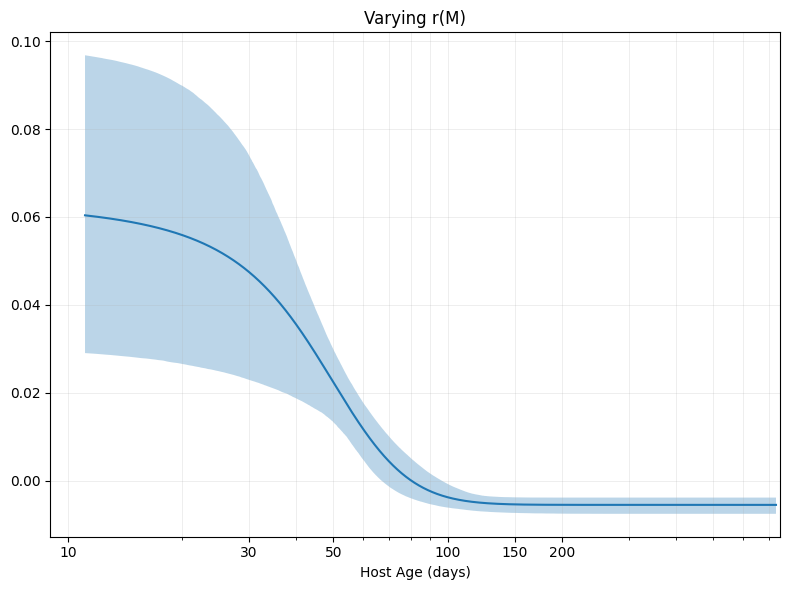

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts2, np.mean(data_neutral.source_rate, axis=0))
axes.fill_between(ts2, np.quantile(data_neutral.source_rate, 0.025, axis=0), np.quantile(data_neutral.source_rate, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.03)
# plt.ylim(1e1, 1e8)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03])
axes.set_xscale('log')
axes.set_xlim(0, 750)
axes.set_xticks([10, 30, 50, 100, 150, 200])
axes.set_xticklabels([10, 30,  50, 100, 150, 200])
# axes.set_ylabel('Source counts (/day)')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying r(M)')
plt.tight_layout()
plt.show()

AttributeError: Unknown variable name: loss_rate
Available variables are sigma, lambda, M_stable, K, S, y1, k_hat, totalMz_mean, MZ_counts_mean, parms, k_hat_pred1, MZ_counts_pred, source_rate, log_lik_Mz, residuals_Mz

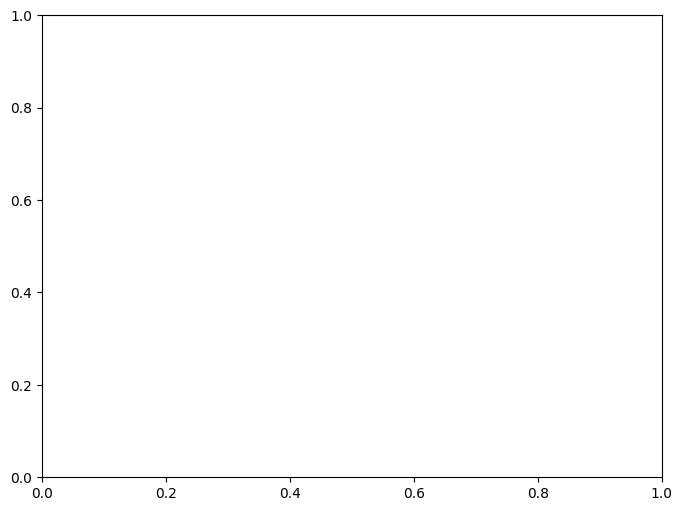

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(np.mean(data_neutral.MZ_counts_pred, axis=0), np.mean(data_neutral.loss_rate, axis=0))
axes.fill_between(np.mean(data_neutral.MZ_counts_pred, axis=0), np.quantile(data_neutral.loss_rate, 0.025, axis=0), np.quantile(data_neutral.loss_rate, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.02)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xscale('log')
# axes.set_xlim(0, 750)
# axes.set_xticks([10, 30, 50, 100, 150, 200])
# axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel(' ')
axes.set_xlabel('MZ counts')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Total number of source cells into MZ (/day)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2544774/736519280.py:14: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axes.set_xlim(0, 750)


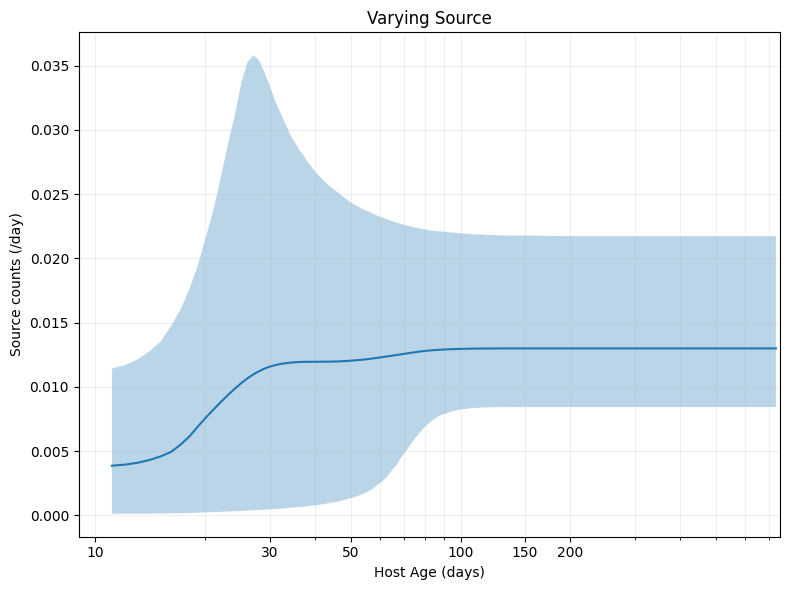

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', alpha=0.85 ,s=85, color = 'Red', label=' T1 Counts')
# sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', alpha=0.85, s=85, color = 'Red', legend=False)
# sns.scatterplot(data=df_new, x='Age at S1K', y='total_T2', alpha=0.85 ,s=85, color = 'Blue', label= 'T2 counts')
# sns.scatterplot(data=df_ont_T2, x='age.at.S1K', y='Transitional2', alpha=0.85, color = 'Blue',s=85, legend=False)
axes.plot(ts2, np.mean(data_neutral.loss_rate, axis=0))
axes.fill_between(ts2, np.quantile(data_neutral.loss_rate, 0.025, axis=0), np.quantile(data_neutral.loss_rate, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.03)
# plt.ylim(1e1, 1e8)
# axes.set_yscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03])
axes.set_xscale('log')
axes.set_xlim(0, 750)
axes.set_xticks([10, 30, 50, 100, 150, 200])
axes.set_xticklabels([10, 30,  50, 100, 150, 200])
axes.set_ylabel('Source counts (/day)')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying Source')
plt.tight_layout()
plt.show()

In [ ]:
# Rate of influx of T1 into MZ

# def phi(t, r_phi):
    # phi = 0.014
    # phi_var = phi / (1 + np.exp(-r_phi * (t-20)))
    # return phi_var
# def phi(t, r_phi):
#     if(t < 40):
#      r_phi = 0.017
#      phi = 0.014
#      phi_var =  phi * (1 - np.exp(-(r_phi) * (t-10)**1.8))
#     else:
#       phi_var = 0.014
#     return(phi_var)

def phi(t, r_phi, alpha, t0):
    phi_value = 0.014  # Assuming phi is a constant value
    phi_var =  ((phi_value - alpha) / (1 + np.exp(-(r_phi) * (t- t0)))) + alpha
    return phi_var

def P(t):

    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

t = np.arange(11, 152, 1)

# influx_p = np.zeros((8000, 739))
# for i in range(0, 739):  # Ensure the loop does not exceed the bounds
#     # influx_p[:, i] = (phi(i + 11, data_neutral.r_phi, data_neutral.alpha) * P(i + 11)) / data_neutral.MZ_counts_pred[:, i]
#     influx_p[:, i] = (phi(i + 11, data_neutral.r_phi) * P(i + 11)) / data_neutral.MZ_counts_pred[:, i]
    

influx_rate = np.zeros((8000, 739))
for i in range(0, 739):  # Ensure the loop does not exceed the bounds
    influx_rate[:, i] = phi(i + 11, data_neutral.r_phi, data_neutral.alpha, data_neutral.t0) 
 


# # influx = np.array(influx)
# print(len(influx_p))
# print(influx_p.shape)
# # print(np.quantile(influx_p, 0.025, axis=0))
# # print(np.quantile(influx_p, 0.975, axis=0))

# # Plot precursor influx with 95% CI

# fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# axes.plot(ts1, np.mean(influx_p, axis=0))
# axes.fill_between(ts1, np.quantile(influx_p, 0.025, axis=0), np.quantile(influx_p, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.15)
# # axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# # axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_xlim(10, 750)
# axes.set_xticks([50, 200, 350, 500])
# axes.set_xticklabels([50, 200, 350, 500])
# axes.set_ylabel('Fraction of influx')
# axes.set_xlabel('Host Age (days)')
# axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# axes.set_title('Proportion of influx of TA44.1 precursor cells into the MZ pool')
# plt.tight_layout()
# plt.show()


AttributeError: Unknown variable name: r_phi
Available variables are sigma, r, K_log, y1, K, k_hat, totalMz_mean, MZ_counts_mean, parms, k_hat_pred1, MZ_counts_pred, source_rate, loss_rate, log_lik_Mz, residuals_Mz

ValueError: x and y must have same first dimension, but have shapes (141,) and (739,)

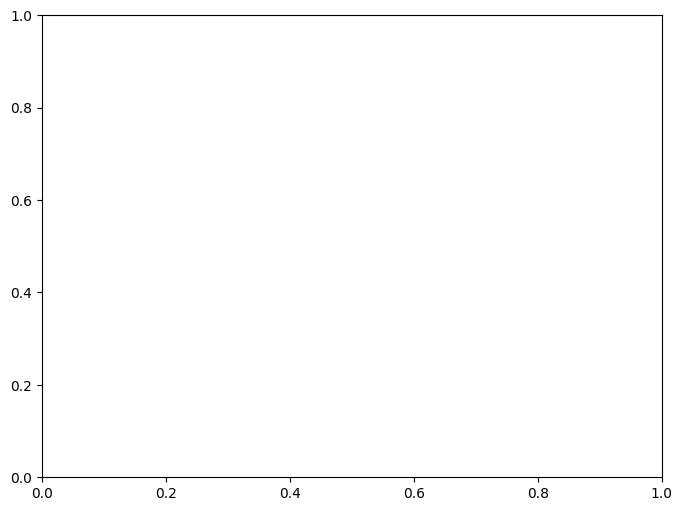

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
ts1= np.arange(11, 152, 1)
axes.plot(ts1, np.mean(influx_rate, axis=0))
axes.fill_between(ts1, np.quantile(influx_rate, 0.025, axis=0), np.quantile(influx_rate, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.02)
axes.set_xscale('log')
# axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
# axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xlim(0, 800)
axes.set_xticks([ 11, 40, 200, 400, 600])
axes.set_xticklabels([ 11, 40, 200, 400, 600])
axes.set_ylabel('Fraction of influx')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Varying influx rate')
plt.tight_layout()
plt.show()